# **DSN HACKATHON 2026**
# **Steps in the Process**
# DSN Mart Sales Prediction

 1. Business Understanding
 2. Data Understanding
 3. Data Cleaning
 4. Exploratory Data Analysis
 5. Feature Engineering/Model Creation
 10. Final Predictions

# **1. Objectives**
      Predict total sales for a product-store combination using historical product and store characteristics,
      while identifying the factors associated with sales performance across DSN Mart's retail network.

# **2. Data Understanding**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# IMPORT DATASETS
train = pd.read_csv('train.csv')
test =  pd.read_csv('test.csv')

In [3]:
train.head()


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
print(train.shape)
print(test.shape)

(6818, 13)
(1705, 12)


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [6]:
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [7]:
train.select_dtypes('object').describe()

,id,product_code,fat_content,product_category,store_code,store_size,store_location_tier,store_format
count,6818,6818,6818,6818,6818,4899,6818,6818
unique,6818,1555,2,48,10,3,3,4
top,row_00000,PRD-YZB4K8,Low Fat,Fruits and Vegetables,STORE-YLW,Medium,Tier_3,Standard Supermarket
freq,1,9,4425,480,754,2218,2677,4462


In [8]:
train.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [9]:
# understanding unique values
for col in train.select_dtypes(include = 'object').columns:
    print(f"\n{col}")
    print(train[col].unique())


id
['row_00000' 'row_00001' 'row_00002' ... 'row_08520' 'row_08521'
 'row_08522']

product_code
['PRD-PRFP9S' 'PRD-PXXK71' 'PRD-V5MOIJ' ... 'PRD-AF3WE8' 'PRD-06GUU9'
 'PRD-7Q5FPH']

fat_content
['Low Fat' 'Regular']

product_category
['Frozen Foods' 'HEALTH AND HYGIENE' 'Canned' 'soft drinks' 'meat'
 'Snack Foods' 'baking goods' 'household' 'Household' 'Dairy' 'dairy'
 'CANNED' 'SNACK FOODS' 'HOUSEHOLD' 'Soft Drinks' 'Fruits and Vegetables'
 'Breakfast' 'Breads' 'Meat' 'BAKING GOODS' 'canned' 'DAIRY' 'breakfast'
 'Baking Goods' 'Health and Hygiene' 'MEAT' 'Seafood'
 'fruits and vegetables' 'frozen foods' 'snack foods' 'FROZEN FOODS'
 'Others' 'FRUITS AND VEGETABLES' 'health and hygiene' 'OTHERS' 'BREADS'
 'SEAFOOD' 'SOFT DRINKS' 'Hard Drinks' 'breads' 'starchy foods'
 'hard drinks' 'HARD DRINKS' 'others' 'Starchy Foods' 'seafood'
 'BREAKFAST' 'STARCHY FOODS']

store_code
['STORE-AGY' 'STORE-YLW' 'STORE-89Z' 'STORE-7WS' 'STORE-9RG' 'STORE-HL7'
 'STORE-JOR' 'STORE-T5G' 'STORE-OYG' 'STOR

## Summary of Data Understanding
- There are missing values in product weight and store size columns
- The unique values in product category are redundant with similar values in different cases

# **3.Data Cleaning**

In [10]:
## convert product category into homogenous case
train['product_category'] = train['product_category'].str.strip().str.title()
test['product_category'] =  test['product_category'].str.strip().str.title()


# Median weight for each product code
weight_map = train.groupby('product_code')['product_weight_kg'].median()

# Fill missing weights using the product's median weight
train['product_weight_kg'] = train['product_weight_kg'].fillna(train['product_code'].map(weight_map))
test['product_weight_kg'] = test['product_weight_kg'].fillna(test['product_code'].map(weight_map))

# Fallback for product codes with no known weight
overall_median = train['product_weight_kg'].median()

train['product_weight_kg'] = train['product_weight_kg'].fillna(overall_median)
test['product_weight_kg'] = test['product_weight_kg'].fillna(overall_median)


#  fill store size by mapping them to their respective store code
size_map = {
    'STORE-7WS': 'Medium',
    'STORE-89Z': 'Medium',
    'STORE-9RG': 'Small',
    'STORE-AGY': 'Large',
    'STORE-HL7': 'Medium',
    'STORE-JOR': 'Small',
    'STORE-T5G': 'Small',
    'STORE-YLW': 'Small'
}

train['store_size'] = train['store_size'].fillna(
    train['store_code'].map(size_map)
)

test['store_size'] = test['store_size'].fillna(
    test['store_code'].map(size_map)
)


# then fill the rest with "Missing"
train['store_size'] = train['store_size'].fillna('Missing')
test['store_size'] = test['store_size'].fillna('Missing')


In [11]:
# Missing product-weight indicator
train["weight_missing"] = train["product_weight_kg"].isna().astype(int)
test["weight_missing"] = test["product_weight_kg"].isna().astype(int)


In [12]:
# handle outlier in total sales
train = train[train['total_sales'] < 10000]


# **Exploratory Data Analysis**

# Numerical Analysis

<Axes: >

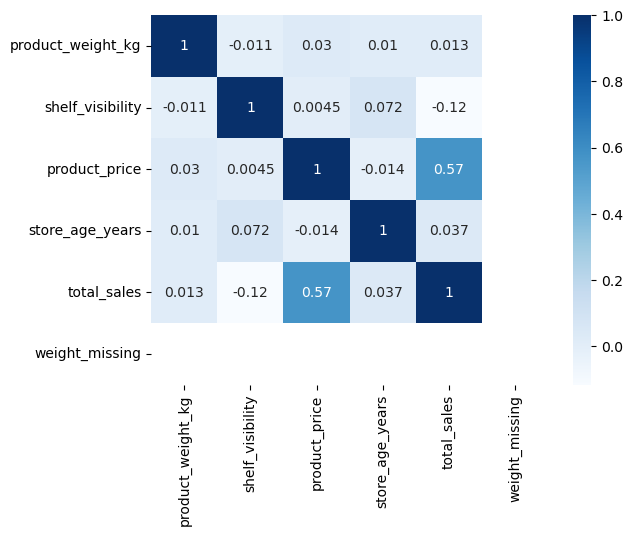

In [13]:
train_num  = train.select_dtypes(include = ['int64' , 'float64'])
sns.heatmap(train_num.corr(),annot = True,cmap = 'Blues')

# sales is highly correlated with price
# followed by a slight negative correlation with shelf visibility and price

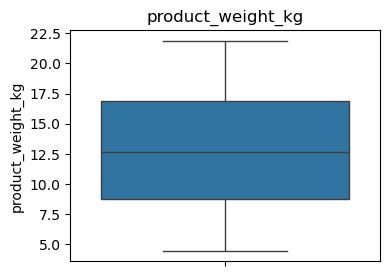

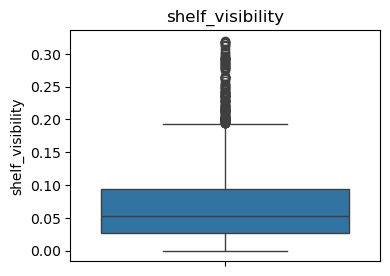

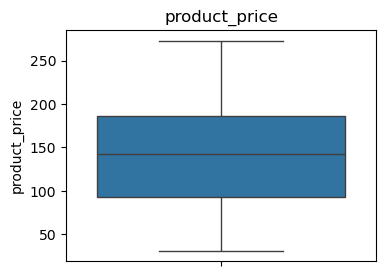

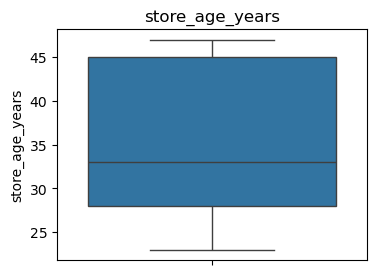

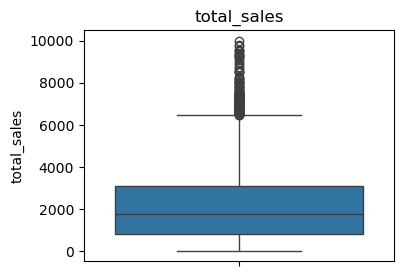

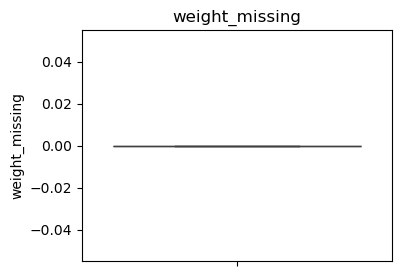

In [14]:
for col in train_num:
    plt.figure(figsize = (4,3))
    sns.boxplot(y = train[col])
    plt.title(col)
    plt.show()

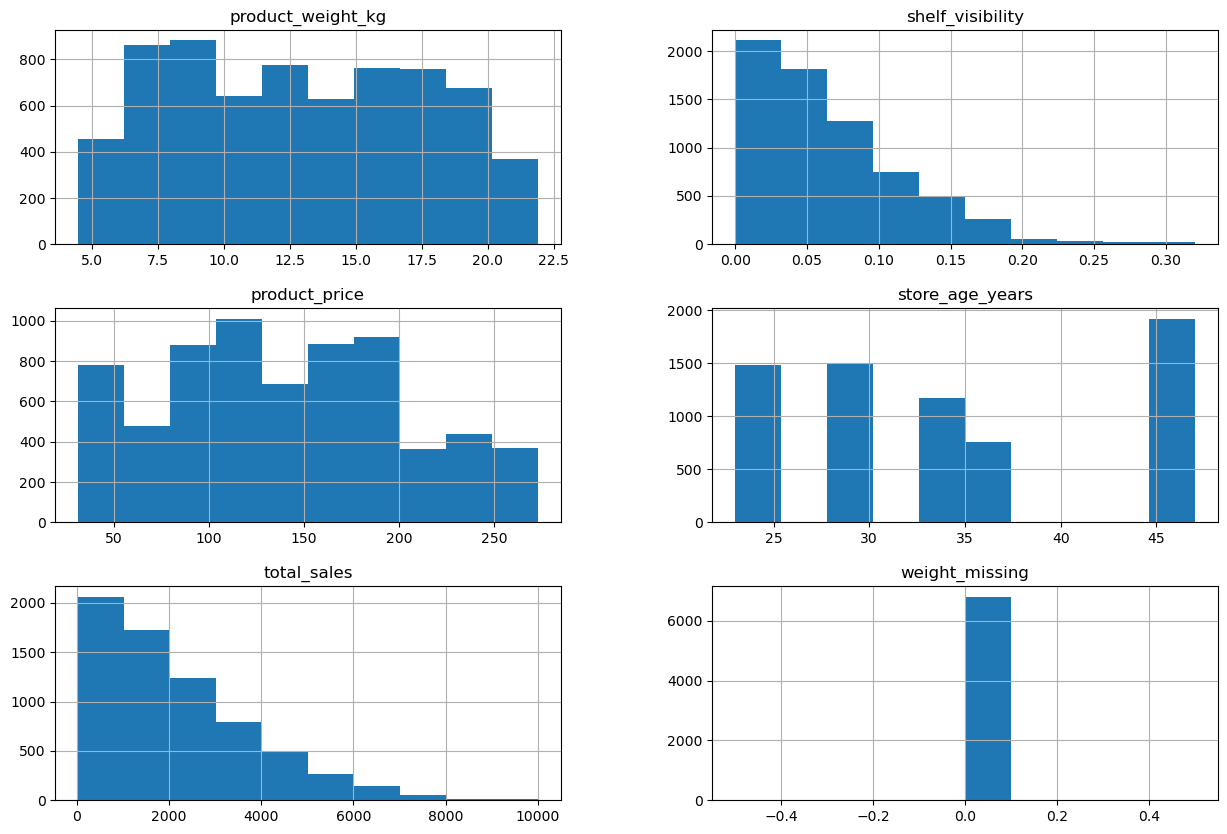

In [15]:
train.hist(figsize = (15,10),)
plt.show()

# Categorical Analysis

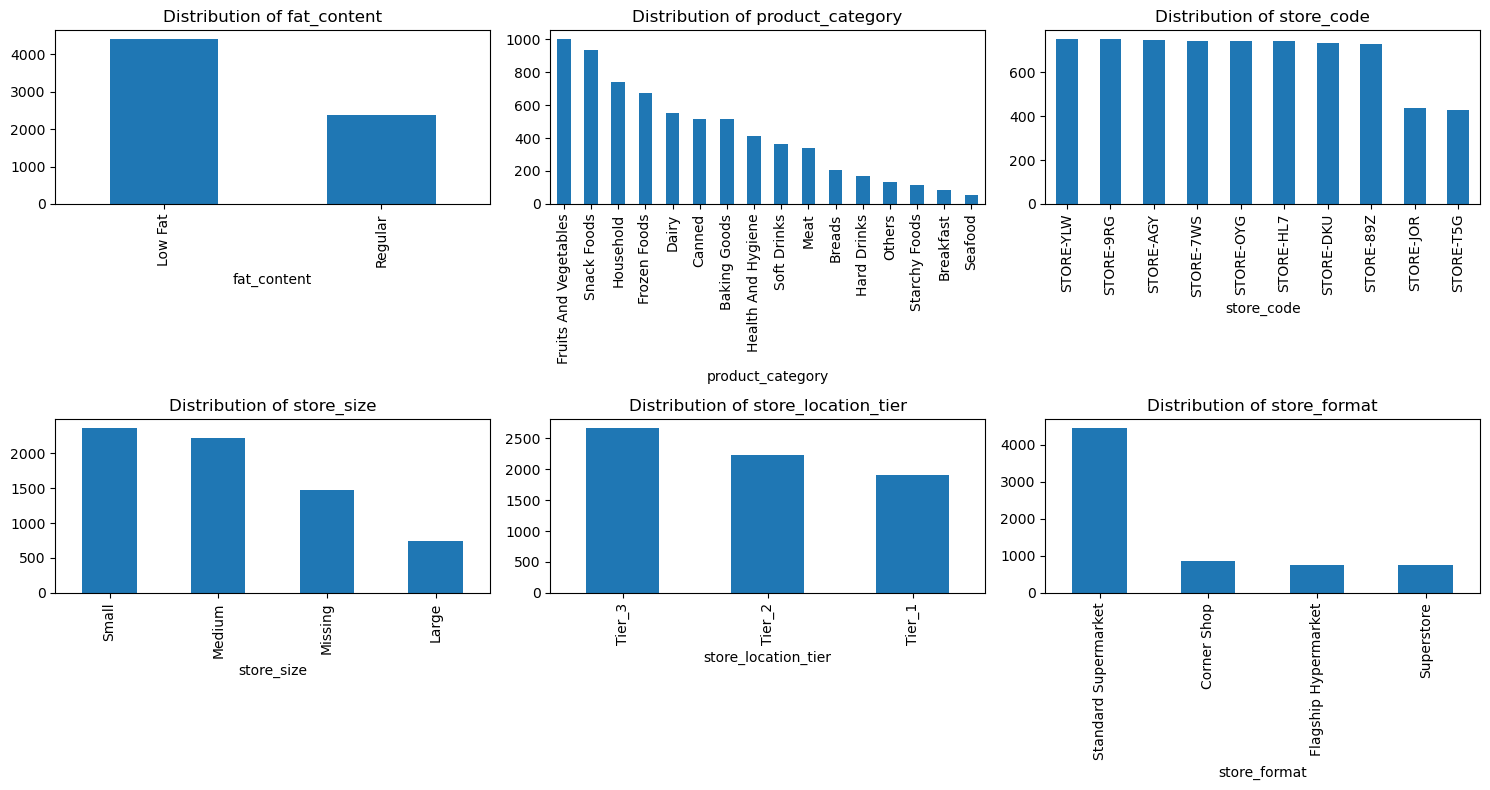

In [16]:
import math
# Define your categorical columns
cat_cols = train.select_dtypes(include='object').columns.drop(['id', 'product_code'])

# Determine layout dimensions (2 rows)
num_cols = len(cat_cols)
n_rows = 2
n_cols = math.ceil(num_cols / n_rows)

# Create the figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Flatten 2D array of axes to easily loop over

# Plot each categorical distribution
for i, col in enumerate(cat_cols):
    train[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        title=f'Distribution of {col}'
    )

# Hide any unused subplots if num_cols is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [17]:
pd.crosstab(train['product_category'],train['fat_content'])

fat_content,Low Fat,Regular
product_category,,
Baking Goods,263,253
Breads,121,88
Breakfast,30,55
Canned,265,252
Dairy,344,208
Frozen Foods,358,317
Fruits And Vegetables,509,496
Hard Drinks,169,0
Health And Hygiene,412,0


In [18]:
pd.crosstab(train['store_format'],train['store_size'],)

store_size,Large,Medium,Missing,Small
store_format,,,,
Corner Shop,0,0,0,866
Flagship Hypermarket,0,745,0,0
Standard Supermarket,748,728,1479,1506
Superstore,0,742,0,0


In [19]:
pd.crosstab(train['store_format'],train['store_code'],)

store_code,STORE-7WS,STORE-89Z,STORE-9RG,STORE-AGY,STORE-DKU,STORE-HL7,STORE-JOR,STORE-OYG,STORE-T5G,STORE-YLW
store_format,,,,,,,,,,
Corner Shop,0,0,0,0,0,0,439,0,427,0
Flagship Hypermarket,745,0,0,0,0,0,0,0,0,0
Standard Supermarket,0,728,752,748,736,0,0,743,0,754
Superstore,0,0,0,0,0,742,0,0,0,0


In [20]:
pd.crosstab(train['store_code'],train['store_size'])

store_size,Large,Medium,Missing,Small
store_code,,,,
STORE-7WS,0,745,0,0
STORE-89Z,0,728,0,0
STORE-9RG,0,0,0,752
STORE-AGY,748,0,0,0
STORE-DKU,0,0,736,0
STORE-HL7,0,742,0,0
STORE-JOR,0,0,0,439
STORE-OYG,0,0,743,0
STORE-T5G,0,0,0,427


In [21]:
pd.crosstab(train['store_format'],train['store_location_tier'])

store_location_tier,Tier_1,Tier_2,Tier_3
store_format,,,
Corner Shop,427,0,439
Flagship Hypermarket,0,0,745
Standard Supermarket,1482,2231,748
Superstore,0,0,742


<function matplotlib.pyplot.show(close=None, block=None)>

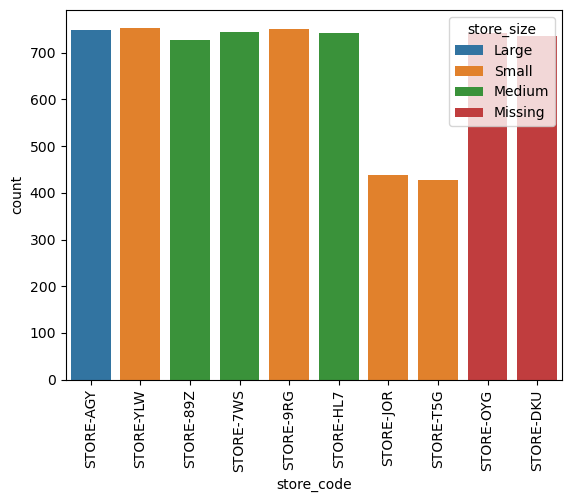

In [22]:
sns.countplot(x = train['store_code'], hue = train['store_size'])
plt.xticks(rotation = 90)
plt.show

# **5. Feature Engineering/Model creation**
  - Create a pipeline for one hot encoding that will be fitted into the model this ensures that we can encode the cat values and still keep the numerical values intact the pipeline will return a 'CSR Matrix. as opposed to a normal dataframe.
  - Create new features such price x product_category

In [23]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [24]:
# Separate features and target
X = train.drop(columns=["total_sales", "id"])
y = train["total_sales"]

X_test = test.drop(columns=["id"])

X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)


Training: (5451, 12)
Validation: (1363, 12)


In [25]:
numeric_features = [
    "product_weight_kg",
    "shelf_visibility",
    "product_price",
    "store_age_years",
    "weight_missing"
]

categorical_features = [
    "fat_content",
    "product_category",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


In [26]:
# Fit preprocessing only on the training split
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

feature_names = preprocessor.get_feature_names_out()

def to_dataframe(matrix, columns, index):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return pd.DataFrame(matrix, columns=columns, index=index)

X_train_processed = to_dataframe(
    X_train_processed, feature_names, X_train.index
)

X_valid_processed = to_dataframe(
    X_valid_processed, feature_names, X_valid.index
)

print("Encoded features:", X_train_processed.shape[1])


Encoded features: 38


In [27]:
# Create price × store interactions
price_col = "num__product_price"

store_columns = [
    col for col in X_train_processed.columns
    if col.startswith("cat__store_code_")
]

print("Store dummy columns:", store_columns)

for store_col in store_columns:
    interaction_name = "price_x_" + store_col

    X_train_processed[interaction_name] = (
        X_train_processed[price_col] *
        X_train_processed[store_col]
    )

    X_valid_processed[interaction_name] = (
        X_valid_processed[price_col] *
        X_valid_processed[store_col]
    )


Store dummy columns: ['cat__store_code_STORE-89Z', 'cat__store_code_STORE-9RG', 'cat__store_code_STORE-AGY', 'cat__store_code_STORE-DKU', 'cat__store_code_STORE-HL7', 'cat__store_code_STORE-JOR', 'cat__store_code_STORE-OYG', 'cat__store_code_STORE-T5G', 'cat__store_code_STORE-YLW']


In [28]:
# Create price × product-category interactions
category_columns = [
    col for col in X_train_processed.columns
    if col.startswith("cat__product_category_")
]

print("Category dummy columns:", category_columns)

for category_col in category_columns:
    interaction_name = "price_x_" + category_col

    X_train_processed[interaction_name] = (
        X_train_processed[price_col] *
        X_train_processed[category_col]
    )

    X_valid_processed[interaction_name] = (
        X_valid_processed[price_col] *
        X_valid_processed[category_col]
    )

print("Final training feature count:", X_train_processed.shape[1])


Category dummy columns: ['cat__product_category_Breads', 'cat__product_category_Breakfast', 'cat__product_category_Canned', 'cat__product_category_Dairy', 'cat__product_category_Frozen Foods', 'cat__product_category_Fruits And Vegetables', 'cat__product_category_Hard Drinks', 'cat__product_category_Health And Hygiene', 'cat__product_category_Household', 'cat__product_category_Meat', 'cat__product_category_Others', 'cat__product_category_Seafood', 'cat__product_category_Snack Foods', 'cat__product_category_Soft Drinks', 'cat__product_category_Starchy Foods']
Final training feature count: 62


In [29]:
# Ordinary Linear Regression
model = LinearRegression()

model.fit(
    X_train_processed,
    y_train
)

valid_predictions = model.predict(X_valid_processed)

rmse = np.sqrt(mean_squared_error(y_valid, valid_predictions))
mae = mean_absolute_error(y_valid, valid_predictions)
r2 = r2_score(y_valid, valid_predictions)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


RMSE: 1038.467308402763
MAE : 746.5554427969154
R2  : 0.6189819522114444


## Final training and Kaggle submission

After checking the validation score above, the following cells retrain the same preprocessing and feature engineering on **all available training data**, then generate the test predictions.


In [30]:
# Fit preprocessing on all training data
X_processed = preprocessor.fit_transform(X) # X here is our full training set
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_processed = to_dataframe(
    X_processed, feature_names, X.index
)

X_test_processed = to_dataframe(
    X_test_processed, feature_names, X_test.index
)


In [31]:
# Price × store interactions on full training/test data
price_col = "num__product_price"

store_columns = [
    col for col in X_processed.columns
    if col.startswith("cat__store_code_")
]

for store_col in store_columns:
    interaction_name = "price_x_" + store_col

    X_processed[interaction_name] = (
        X_processed[price_col] *
        X_processed[store_col]
    )

    X_test_processed[interaction_name] = (
        X_test_processed[price_col] *
        X_test_processed[store_col]
    )


In [32]:
# Price × category interactions on full training/test data
category_columns = [
    col for col in X_processed.columns
    if col.startswith("cat__product_category_")
]

for category_col in category_columns:
    interaction_name = "price_x_" + category_col

    X_processed[interaction_name] = (
        X_processed[price_col] *
        X_processed[category_col]
    )

    X_test_processed[interaction_name] = (
        X_test_processed[price_col] *
        X_test_processed[category_col]
    )

print("Final feature count:", X_processed.shape[1])


Final feature count: 62


In [33]:
# Final Linear Regression model
final_model = LinearRegression()

final_model.fit(X_processed,y)

test_predictions = final_model.predict(X_test_processed)

# Sales cannot be negative
test_predictions = np.maximum(test_predictions, 0)

print("Predictions generated:", len(test_predictions))
print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())


Predictions generated: 1705
Minimum prediction: 4.98405258651681
Maximum prediction: 6492.410192536873


In [34]:
# Create Kaggle submission
submission = pd.DataFrame({"id": test["id"],"total_sales": test_predictions})

submission.to_csv(r"C:\Users\hp\Desktop\DSN Hackathon\linear_regression_1064_submission_5.csv",index=False)

print(submission.head())
print("\nSubmission shape:", submission.shape)
print("\nSaved as: linear_regression_1064_submission_6.csv")


          id  total_sales
0  row_00009  2656.919598
1  row_00015  4597.063366
2  row_00019  2972.656256
3  row_00020  3143.880561
4  row_00023  2541.349098

Submission shape: (1705, 2)

Saved as: linear_regression_1064_submission_6.csv
